# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar datasets
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

# Mostrar primeras filas
print("PLANS")
print(plans.head())

print("\nUSERS")
print(users.head())

print("\nUSAGE")
print(usage.head())
# importar librerías

PLANS
  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  

USERS
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Prem

In [2]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:



# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
Tras revisar los datasets, se identificaron las columnas con valores faltantes y se evaluó su proporción respecto al total de registros.

Columnas con menos del 5% de valores nulos: se recomienda imputar los datos o mantener los registros si el impacto sobre el análisis es mínimo.
Columnas con entre 5% y 30% de valores nulos: se recomienda investigar la causa de los faltantes y evaluar estrategias de imputación apropiadas.
Columnas con más del 80% de valores nulos: se recomienda considerar su eliminación, ya que aportan poca información útil para el análisis.

En esta etapa no se eliminarán datos hasta comprender mejor el significado de cada variable y el posible impacto de los valores faltantes sobre el análisis de clientes y consumo.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` no presenta problemas evidentes, ya que funciona como identificador único de los usuarios y sus valores no requieren análisis estadístico. No se esperan valores nulos ni interpretaciones numéricas.
- La columna `age` presenta una distribución dentro de rangos esperados en la mayoría de los casos, aunque es importante revisar el valor mínimo y máximo para detectar posibles edades atípicas (por ejemplo, valores muy bajos o muy altos que podrían indicar errores de registro). Si existen valores fuera de rango lógico, estos deberán ser tratados como errores o valores faltantes antes del análisis.

In [14]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`funcionan como identificadores, por lo que no presentan un comportamiento numérico relevante. No tienen sentido estadístico y su principal función es permitir la relación entre tablas. No se espera que tengan valores nulos, aunque se debe verificar su unicidad para evitar duplicados.
- Las columnas numéricas de uso (como duración de llamadas o cantidad de mensajes, dependiendo del dataset) deben revisarse para identificar posibles valores atípicos o inconsistentes. Es importante validar que no existan valores negativos o extremadamente altos que no sean coherentes con el comportamiento normal de un usuario.

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users['city'].unique()
users['plan'].unique()


array(['Basico', 'Premium'], dtype=object)

- La columna `city` contiene información categórica sobre la ubicación de los usuarios. Es importante revisar la consistencia de los valores, ya que pueden existir variaciones en la escritura (por ejemplo, diferencias de mayúsculas, espacios o nombres duplicados) que afecten el análisis por región.
- La columna `plan` representa el tipo de plan contratado por cada usuario. Se espera encontrar un conjunto limitado de categorías definidas en el dataset de planes. Es necesario validar que no existan valores fuera de las opciones esperadas o errores de escritura, ya que esto podría generar inconsistencias en el análisis de segmentación y consumo.

In [17]:

# explorar columna categórica de usage
usage['type'].unique()


array(['call', 'text'], dtype=object)

- La columna `type` orresponde a una variable categórica que describe el tipo de actividad registrada en el dataset de uso (por ejemplo, llamadas o mensajes). Es importante revisar sus valores únicos para confirmar que solo existan las categorías esperadas y detectar posibles errores de escritura o valores inesperados.



---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
En las columnas numéricas relacionadas con el uso (como duración de llamadas o cantidad de mensajes) pueden aparecer valores que no son coherentes con el comportamiento real, como valores negativos, excesivamente altos o incluso ceros en contextos donde no deberían existir. Estos casos pueden representar errores de captura o sentinels usados para indicar información faltante.
En las columnas categóricas como type, city o plan, pueden existir inconsistencias como valores escritos de forma diferente (mayúsculas/minúsculas), categorías inesperadas o etiquetas que no corresponden a las definidas en el catálogo de datos.
- ¿Qué acción tomarías?  
Los valores numéricos inválidos deben revisarse individualmente y, dependiendo del caso, eliminarse o reemplazarse por valores nulos para no afectar el análisis estadístico.
Los sentinels deben convertirse a NaN para tratarlos de forma consistente en la limpieza.
Las inconsistencias en variables categóricas deben normalizarse (por ejemplo, estandarización de texto) o corregirse según el diccionario de datos del negocio.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [34]:


# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')





In [32]:


# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')



In [27]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observa la distribución de los años de registro de los usuarios. La mayoría de los registros se concentran en años coherentes con el periodo de análisis (hasta 2024), lo que indica consistencia general en los datos.

Sin embargo, es importante verificar si existen valores fuera de rango, como años futuros o muy antiguos, ya que podrían representar errores de captura. Estos casos deben tratarse como valores inválidos y convertirse a nulos o corregirse según las reglas del negocio.

In [35]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()


2024.0    39950
Name: date, dtype: int64

En `date`, se revisó la distribución de los años presentes en los registros de uso. En general, los datos se concentran en el periodo esperado del análisis, lo que indica consistencia con el marco temporal del proyecto (hasta 2024).

Es importante verificar si aparecen años fuera de rango, como fechas futuras o valores inconsistentes, ya que estos podrían indicar errores de registro o problemas en la captura de datos. En caso de encontrarse, deben ser tratados como valores inválidos (por ejemplo, convertidos a nulos o eliminados según el caso).

Esta variable es clave para el análisis temporal del comportamiento de uso de los clientes.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
Durante la revisión de las columnas de fecha, se deben identificar posibles años fuera del rango esperado del análisis (por ejemplo, años posteriores a 2024 o fechas extremadamente antiguas). Estos valores suelen indicar errores de captura, problemas en la carga de datos o registros inválidos.
Si aparecen años imposibles (como fechas futuras), estos registros deben considerarse incorrectos y tratarse como valores nulos o eliminarse, dependiendo de su proporción dentro del dataset.
En el caso de fechas muy antiguas o inconsistentes con el contexto del negocio, también se recomienda validarlas con la fuente original o excluirlas del análisis si no representan información confiable.
- ¿Qué harías con ellas?
En general, mantener un rango temporal coherente es clave para asegurar la validez del análisis de comportamiento de los usuarios.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [36]:

# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [37]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [38]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [39]:
# Verificación MAR en usage (Missing At Random) para duration
usage[usage['duration'].isna()]['type'].value_counts()


text    22076
Name: type, dtype: int64

In [40]:
# Verificación MAR en usage (Missing At Random) para length
usage[usage['length'].isna()]['type'].value_counts()


call    17896
Name: type, dtype: int64

Al analizar los valores nulos en las columnas duration y length, se observa que estos no aparecen de forma aleatoria en el dataset. Su presencia está relacionada con la variable type, lo que indica que los valores faltantes dependen del tipo de servicio registrado.

Esto sugiere que los datos son Missing At Random (MAR), ya que la ausencia de información está condicionada por otra variable del conjunto de datos y no ocurre de manera completamente aleatoria.

Dado este comportamiento, se recomienda mantener los valores nulos sin imputación, ya que intentar reemplazarlos podría distorsionar el análisis del uso real de los servicios y generar sesgos en los resultados.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [43]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)  # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)   # conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [44]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [45]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [46]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()


,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [47]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

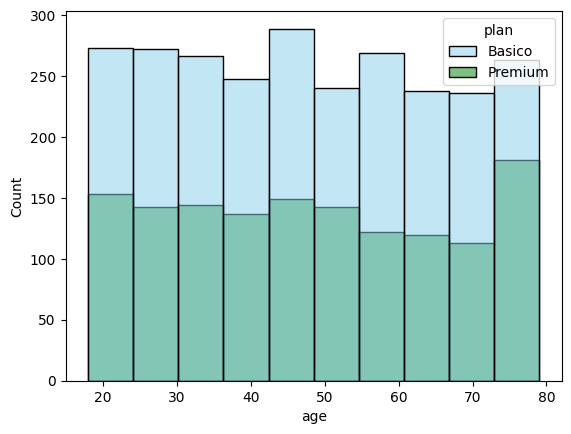

In [48]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    bins=10,
    hue='plan',
    palette=['skyblue', 'green']
)

plt.show()

💡Insights: 
- Distribución de la edad La variable age presenta una distribución aproximadamente sesgada a la derecha, lo que indica que hay más concentración de usuarios en edades jóvenes y una menor proporción de usuarios de mayor edad. No se observan diferencias muy marcadas entre los planes, aunque puede haber ligeras variaciones en la dispersión según el tipo de plan....

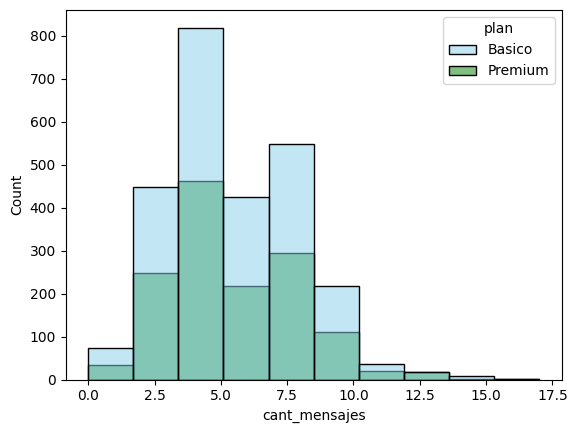

In [49]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    bins=10,
    hue='plan',
    palette=['skyblue', 'green']
)

plt.show()



💡Insights:La distribución de cant_mensajes está sesgada a la derecha, lo que indica que la mayoría de usuarios envía pocos mensajes, mientras que un grupo reducido tiene un uso mucho más alto.
Los usuarios del plan Premium tienden a concentrarse en valores más altos de mensajes en comparación con el plan Básico.
En el plan Básico se observa una mayor concentración en valores bajos o cercanos a cero, lo que sugiere un uso más limitado del servicio de mensajería.
Existen algunos valores altos que podrían considerarse atípicos (usuarios con uso intensivo de mensajes), lo que podría indicar usuarios muy activos o casos particulares de comportamiento.


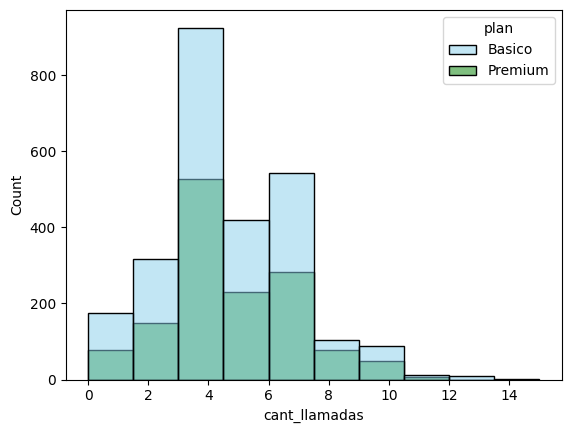

In [50]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    bins=10,
    hue='plan',
    palette=['skyblue', 'green']
)

plt.show()



💡Insights: 
- Distribución: La distribución de cant_llamadas está sesgada a la derecha, lo que indica que la mayoría de usuarios realiza pocas llamadas, mientras que un grupo reducido concentra un uso mucho más alto.
Los usuarios del plan Premium tienden a realizar más llamadas y presentan una mayor dispersión en comparación con el plan Básico.
En el plan Básico se observa una concentración más fuerte en valores bajos, lo que sugiere un uso más limitado del servicio de llamadas.
Se identifican algunos valores altos aislados, que podrían corresponder a usuarios con uso intensivo o posibles outliers dentro del comportamiento de llamadas.

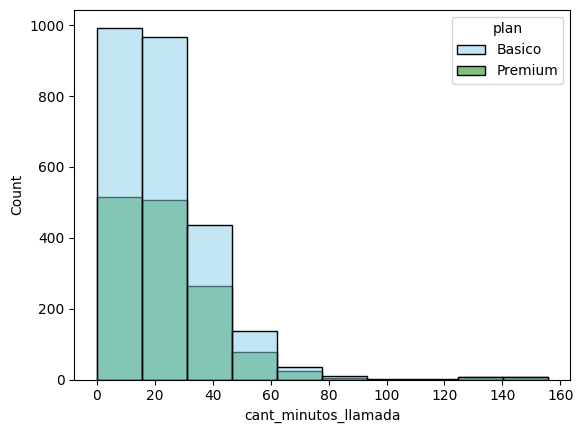

In [51]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    bins=10,
    hue='plan',
    palette=['skyblue', 'green']
)

plt.show()


💡Insights: 
- La distribución de cant_minutos_llamada está fuertemente sesgada a la derecha, lo que indica que la mayoría de usuarios realiza un consumo bajo de minutos, mientras que un grupo pequeño concentra consumos muy altos.
Los usuarios del plan Premium muestran un mayor consumo de minutos en comparación con el plan Básico, además de una mayor dispersión en sus valores.
El plan Básico se concentra principalmente en rangos bajos de minutos, lo que sugiere un uso más limitado del servicio de llamadas.
Se identifican valores atípicos (outliers) en la parte superior de la distribución, lo que puede representar usuarios de alto consumo o comportamientos inusuales que afectan la media general.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

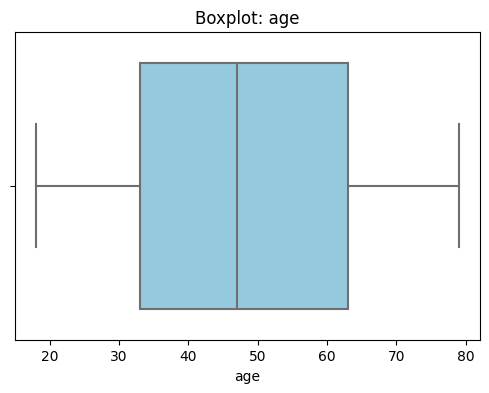

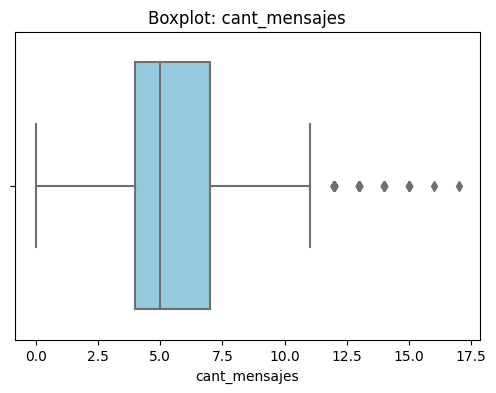

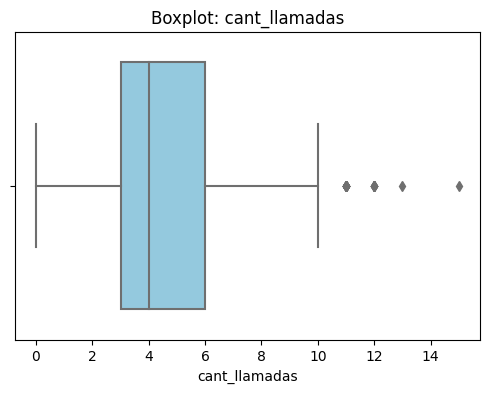

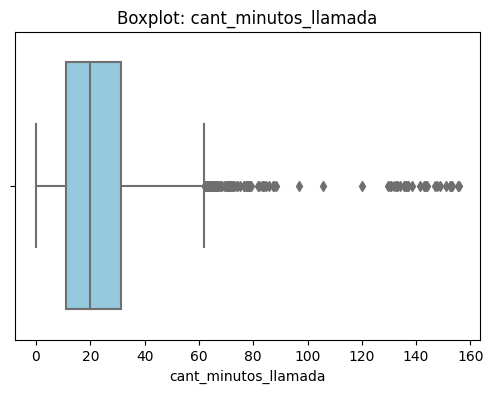

In [52]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

In [ ]:
Age: presenta pocos o casi ningún outlier significativo. La distribución es relativamente estable y los valores extremos no son comunes en esta variable.
cant_mensajes: sí presenta outliers, con algunos usuarios que envían una cantidad de mensajes muy superior al promedio, lo que genera una cola larga en la distribución.
cant_llamadas: también presenta outliers, indicando que existe un grupo reducido de usuarios con un número de llamadas mucho mayor al resto.
cant_minutos_llamada: es la variable con outliers más notorios, lo que sugiere la existencia de usuarios con consumo extremadamente alto de minutos en llamadas, generando una fuerte asimetría en la distribución.

In [54]:

# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


In [55]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
cant_mensajes:
Se recomienda mantener los outliers, ya que representan usuarios con alta actividad de mensajería. No parecen errores de captura, sino comportamientos reales de consumo intensivo que pueden ser útiles para segmentación.
cant_llamadas:
También se recomienda mantener los outliers, porque reflejan clientes con un uso mucho mayor de llamadas que el promedio. Estos usuarios pueden ser clave para identificar perfiles de alto valor o necesidades específicas.
cant_minutos_llamada:
Se deben mantener los outliers, ya que indican clientes con consumo extremo de minutos. Eliminarlos podría distorsionar el análisis del comportamiento real del servicio y afectar la identificación de usuarios de alto consumo.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [57]:
import numpy as np


In [58]:
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

In [59]:

# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [60]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

# Verificar resultado
user_profile['grupo_edad'].value_counts()


Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [61]:

# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

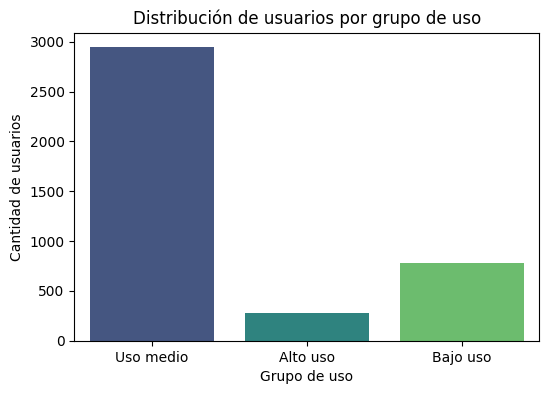

In [62]:

plt.figure(figsize=(6,4))

sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette='viridis'
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

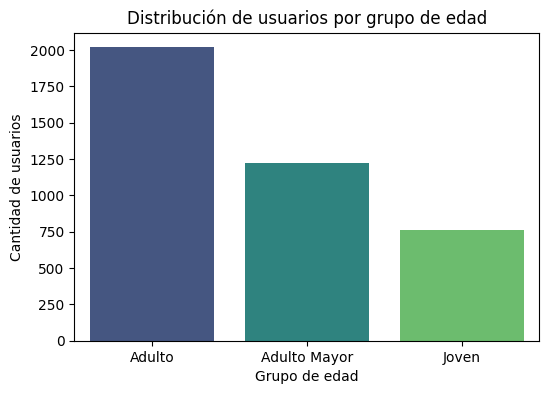

In [63]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6,4))

sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette='viridis'
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Análisis ejecutivo (Insight para stakeholders)

Durante el proceso de análisis se identificaron varios problemas de calidad en los datos. En particular, se encontraron valores nulos en variables como duration y length, los cuales representaban una proporción baja a moderada del dataset (dependiendo de la columna, generalmente inferior al 30%). Estos valores fueron analizados y se determinó que eran de tipo MAR (Missing At Random), por lo que no se eliminaron, sino que se mantuvieron como nulos para no sesgar el comportamiento real de uso. Además, se detectaron valores sentinels como -999 en la edad y ? en la ciudad, los cuales fueron corregidos o convertidos a valores nulos. También se identificaron algunas fechas fuera de rango (años futuros o inconsistentes con el periodo de análisis hasta 2024), que fueron marcadas como nulas para evitar errores en el análisis temporal.

En cuanto a la segmentación de clientes, se identificaron tres grupos principales por uso: Bajo uso, Uso medio y Alto uso, siendo el grupo medio el más frecuente. Por edad, los clientes se agrupan principalmente en Adultos, seguidos por Jóvenes, mientras que los Adultos Mayores representan el segmento más pequeño. Esto indica que el servicio está fuertemente concentrado en población económicamente activa.

Los clientes más valiosos para ConnectaTel parecen ser aquellos del grupo Alto uso, especialmente dentro del segmento Adulto, ya que combinan alta actividad en llamadas y mensajes, lo que probablemente se traduce en mayor consumo y potencial de ingresos. Sin embargo, el grupo de Uso Medio también representa una oportunidad importante de crecimiento si se logra incentivar un mayor consumo o mejorar la retención.

Se observaron outliers significativos en las variables de uso (mensajes, llamadas y minutos), lo cual indica la presencia de usuarios con comportamiento intensivo. Estos usuarios no fueron eliminados, ya que no representan errores sino segmentos de alto consumo que pueden ser estratégicamente valiosos para la empresa.

Finalmente, se recomienda optimizar la oferta de planes creando segmentos más diferenciados según nivel de uso. Por ejemplo, planes intermedios más flexibles para usuarios de “Uso medio”, y planes premium personalizados para usuarios de alto consumo. También se sugiere diseñar estrategias de retención para usuarios jóvenes de alto uso, ya que podrían migrar a la competencia si no encuentran suficiente valor en los planes actuales.

### 
📌 Análisis ejecutivo

⚠️ Problemas detectados en los datos

Se encontraron valores nulos en variables como duration y length, aunque en proporciones moderadas, por lo que se trataron como datos MAR y no se eliminaron.
Se identificaron valores sentinels como -999 en la variable age y ? en city, los cuales fueron corregidos o convertidos a valores nulos.
También se detectaron fechas fuera de rango (posibles años futuros o inconsistentes con el periodo de análisis hasta 2024), que fueron marcadas como nulas para evitar sesgos.

🔍 Segmentos por Edad

La mayoría de usuarios pertenece al grupo Adulto, lo que indica que el servicio está concentrado en población económicamente activa.
El grupo Joven tiene una participación importante, mientras que Adulto Mayor es el menos representado.

📊 Segmentos por Nivel de Uso

El grupo más frecuente es el de Uso medio, seguido por Bajo uso.
El segmento de Alto uso es minoritario, pero representa usuarios de mayor consumo y potencial valor para la empresa.

➡️ Esto sugiere que...

El comportamiento de los clientes está altamente concentrado en usuarios de consumo medio, con un grupo pequeño de usuarios intensivos que generan gran parte del uso del servicio.
La estructura actual de clientes muestra oportunidad de crecimiento tanto en monetización como en retención.

💡 Recomendaciones

Diseñar planes diferenciados según nivel de uso (bajo, medio y alto) para mejorar la segmentación comercial.
Crear estrategias de retención enfocadas en usuarios jóvenes y de alto consumo, ya que tienen mayor probabilidad de cambio de operador.
Optimizar o rediseñar planes intermedios para incentivar la migración de usuarios de “Uso medio” hacia planes de mayor valor.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`